## **Bibliotecas**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import plotly.express as px
import plotly.graph_objects as go
import prophet
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import calendar

## **Base de dados**

In [4]:
## Extraído de um repositório da Alura(GitHub)
raw = 'https://raw.githubusercontent.com/alura-cursos/series_temporais_prophet/refs/heads/main/Dados/poluentes.csv'

In [5]:
df = pd.read_csv(raw)

df.head()

,Data,PM2.5,PM10,SO2,NO2,CO,O3,TEMP
0,2020-03-01,7.0,11.0,12.0,23.0,429.0,64.0,1.0
1,2020-03-02,31.0,42.0,37.0,67.0,825.0,30.0,1.0
2,2020-03-03,77.0,121.0,61.0,81.0,1621.0,19.0,6.0
3,2020-03-04,23.0,45.0,23.0,46.0,606.0,54.0,10.0
4,2020-03-05,149.0,184.0,94.0,133.0,2358.0,68.0,6.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Data    1460 non-null   object 
 1   PM2.5   1460 non-null   float64
 2   PM10    1460 non-null   float64
 3   SO2     1460 non-null   float64
 4   NO2     1460 non-null   float64
 5   CO      1460 non-null   float64
 6   O3      1460 non-null   float64
 7   TEMP    1460 non-null   float64
dtypes: float64(7), object(1)
memory usage: 91.4+ KB


In [7]:
df_temporal = df.copy()

In [8]:
df_temporal['Data'] = pd.to_datetime(df['Data'])
df_temporal.set_index('Data', inplace=True, drop=True)
df_temporal.head()

,PM2.5,PM10,SO2,NO2,CO,O3,TEMP
Data,,,,,,,
2020-03-01,7.0,11.0,12.0,23.0,429.0,64.0,1.0
2020-03-02,31.0,42.0,37.0,67.0,825.0,30.0,1.0
2020-03-03,77.0,121.0,61.0,81.0,1621.0,19.0,6.0
2020-03-04,23.0,45.0,23.0,46.0,606.0,54.0,10.0
2020-03-05,149.0,184.0,94.0,133.0,2358.0,68.0,6.0


In [9]:
df_temporal.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1460 entries, 2020-03-01 to 2024-02-28
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   PM2.5   1460 non-null   float64
 1   PM10    1460 non-null   float64
 2   SO2     1460 non-null   float64
 3   NO2     1460 non-null   float64
 4   CO      1460 non-null   float64
 5   O3      1460 non-null   float64
 6   TEMP    1460 non-null   float64
dtypes: float64(7)
memory usage: 91.2 KB


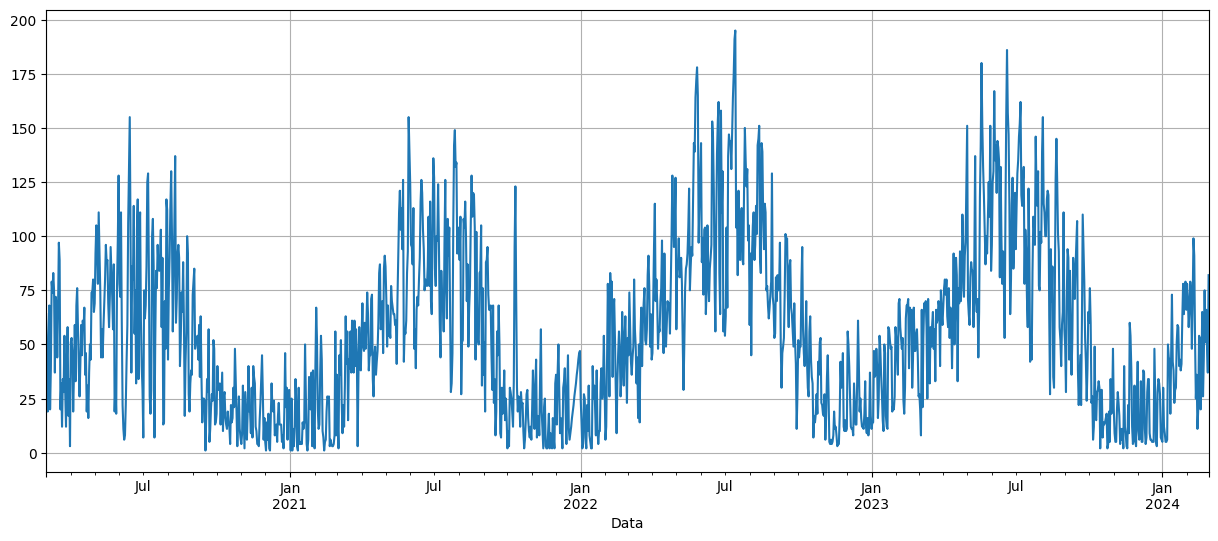

In [10]:
df_temporal['O3'].plot(figsize=(15,6), grid=True);

In [11]:
px.line(data_frame=df_temporal,
        x=df_temporal.index,
        y='O3',
        title='Medição (O3) de 2020 a 2024')


In [12]:
df_2022 = df_temporal[df_temporal.index.year == 2022].copy()
df_2022['mes'] = df_2022.index.month
df_2022 = df_2022.groupby('mes')['O3'].mean().reset_index()
df_2022['mes'] = df_2022['mes'].apply(lambda x: calendar.month_abbr[x])

px.bar(data_frame=df_2022,
       x='mes',
       y='O3',
       title='Mediação do O3 no período de 2022',
       text_auto='.2f',
       width=1100)

## **Prophet**

In [13]:
## Divisão para o modelo Prophet
df_prophet = df_temporal['O3'].reset_index()
df_prophet.columns = ['ds', 'y']

In [14]:
## Realizando o treinamento com o Prophet
from prophet import Prophet

np.random.seed(4587)

model_prophet = Prophet(daily_seasonality=False)

model_prophet.fit(df_prophet);

In [15]:
futuro = model_prophet.make_future_dataframe(periods=360, freq='D')
previsao = model_prophet.predict(futuro)

In [16]:
from prophet.plot import plot_plotly

fig = plot_plotly(model_prophet, previsao)
fig.show()

In [17]:
from prophet.plot import plot_components_plotly

plot_components_plotly(model_prophet, previsao)

/usr/local/lib/python3.12/dist-packages/plotly/io/_json.py:560: UserWarning:

Discarding nonzero nanoseconds in conversion.



In [18]:
from pandas.core.frame import DataFrame
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Avaliação do Modelo
def fazer_previsao(teste: DataFrame, previsao: DataFrame) -> None:
    previsao = model_prophet.predict(teste[['ds']])
    mae = mean_absolute_error(teste['y'], previsao['yhat'])
    rmse = np.sqrt(mean_squared_error(teste['y'], previsao['yhat']))

    print('--'*20)
    print("Avaliando o modelo...")
    print('--'*20)
    print("Resultados:")
    print(f"MAE: {mae:.3f}")
    print(f"RMSE: {rmse:.3f}")
    print('--'*20)

## **Dividindo em treino e teste**

In [19]:
## Divindo em treino e teste
divisao = int(len(df_prophet)* 0.8)

treino = df_prophet.iloc[:divisao]
teste = df_prophet.iloc[divisao:]

treino.shape, teste.shape

((1168, 2), (292, 2))

In [20]:
display(treino.head(2))
print()
display(teste.head(2))

,ds,y
0,2020-03-01,64.0
1,2020-03-02,30.0


,ds,y
1168,2023-05-13,65.0
1169,2023-05-14,71.0


In [21]:
## Realizando o treinamento com o Prophet
from prophet import Prophet

np.random.seed(4587)

model_prophet = Prophet(daily_seasonality=False)

model_prophet.fit(treino);

In [22]:
futuro = model_prophet.make_future_dataframe(periods=360, freq='D')
previsao = model_prophet.predict(futuro)

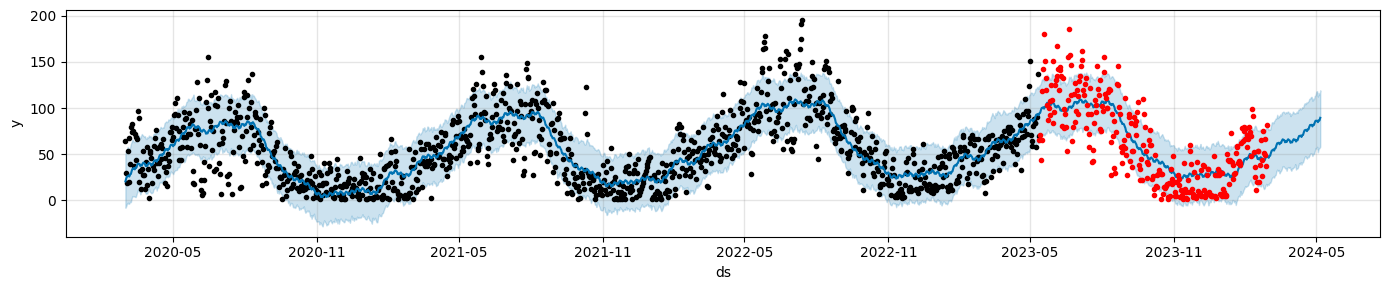

In [23]:
model_prophet.plot(previsao, figsize=(14,3))
plt.plot(teste['ds'], teste['y'], '.r')
plt.show()

In [24]:
fazer_previsao(teste, previsao)

----------------------------------------
Avaliando o modelo...
----------------------------------------
Resultados:
MAE: 21.967
RMSE: 26.660
----------------------------------------


## **Aprimorando s/ Outliers**

In [25]:
## Excluindo outliers
previsao.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2020-03-01,38.053004,-8.014490,50.076354,38.053004,38.053004,-17.478210,-17.478210,-17.478210,-1.451718,-1.451718,-1.451718,-16.026492,-16.026492,-16.026492,0.0,0.0,0.0,20.574794
1,2020-03-02,38.072273,-6.493894,53.644002,38.072273,38.072273,-14.532466,-14.532466,-14.532466,0.545796,0.545796,0.545796,-15.078262,-15.078262,-15.078262,0.0,0.0,0.0,23.539807
2,2020-03-03,38.091541,-3.729628,55.723985,38.091541,38.091541,-12.261423,-12.261423,-12.261423,1.782325,1.782325,1.782325,-14.043748,-14.043748,-14.043748,0.0,0.0,0.0,25.830119
3,2020-03-04,38.110810,-2.436722,57.801298,38.110810,38.110810,-11.891183,-11.891183,-11.891183,1.048196,1.048196,1.048196,-12.939378,-12.939378,-12.939378,0.0,0.0,0.0,26.219627
4,2020-03-05,38.130078,-3.837360,55.199761,38.130078,38.130078,-11.181723,-11.181723,-11.181723,0.601331,0.601331,0.601331,-11.783055,-11.783055,-11.783055,0.0,0.0,0.0,26.948355


In [26]:
## Divisão para o modelo Prophet
df_prophet = df_temporal['O3'].reset_index()
df_prophet.columns = ['ds', 'y']

df_prophet

,ds,y
0,2020-03-01,64.0
1,2020-03-02,30.0
2,2020-03-03,19.0
3,2020-03-04,54.0
4,2020-03-05,68.0
...,...,...
1455,2024-02-24,51.0
1456,2024-02-25,66.0
1457,2024-02-26,49.0
1458,2024-02-27,37.0


In [27]:
## Buscando os Outliers
df_prophet_merge_previsao = previsao.merge(df_prophet, on='ds', how='inner')

outlier_inferior = (df_prophet_merge_previsao['y'] >= df_prophet_merge_previsao['yhat_lower'])
outlier_superior = (df_prophet_merge_previsao['y'] <= df_prophet_merge_previsao['yhat_upper'])

df_sem_outliers = df_prophet_merge_previsao[outlier_inferior & outlier_superior][['ds', 'y']].reset_index(drop=True)

total_outliers_excluidos = df_prophet_merge_previsao.shape[0] - df_sem_outliers.shape[0]
print(f"Total dos novos antigo: {df_prophet_merge_previsao.shape[0]}")
print(f"Total dos novos dados: {df_sem_outliers.shape[0]}")
print(f"Foram removido: {total_outliers_excluidos} outliers")

Total dos novos antigo: 1460
Total dos novos dados: 1187
Foram removido: 273 outliers


In [28]:
## Nova divisao dos dados
divisao_sem_outliers = int(len(df_sem_outliers)*0.8)

treino_sem_outliers = df_sem_outliers.iloc[:divisao_sem_outliers]
teste_sem_outliers = df_sem_outliers.iloc[divisao_sem_outliers:]

treino_sem_outliers.shape, teste_sem_outliers.shape

((949, 2), (238, 2))

In [29]:
from prophet import Prophet

model_prophet_sem_outlier = Prophet(daily_seasonality=False)

model_prophet_sem_outlier.fit(treino_sem_outliers);

In [30]:
futuro = model_prophet_sem_outlier.make_future_dataframe(periods=360, freq='D')
pred_sem_outliers = model_prophet_sem_outlier.predict(futuro)

In [31]:
from prophet.plot import plot_plotly

plot_plotly(model_prophet_sem_outlier, pred_sem_outliers)

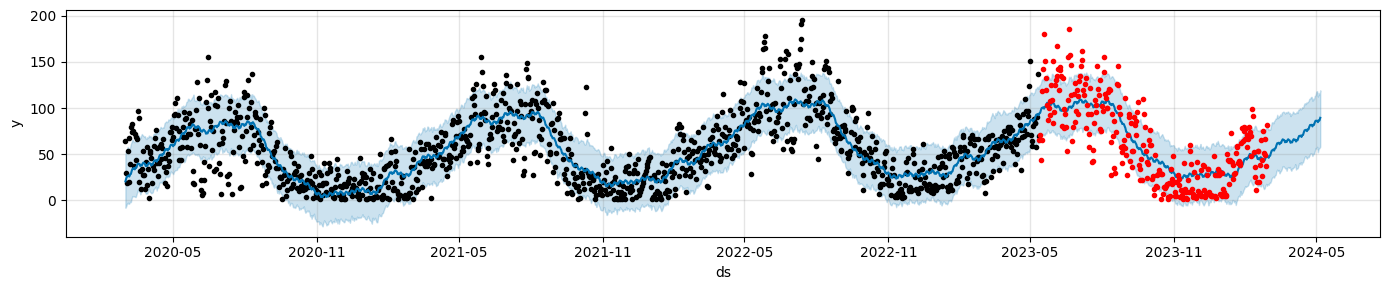

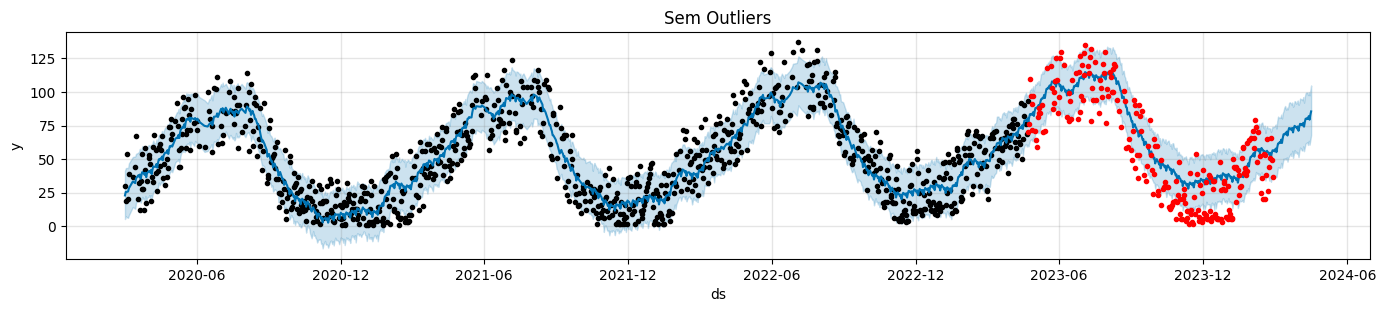

In [32]:
model_prophet.plot(previsao, figsize=(14,3))
plt.plot(teste['ds'], teste['y'], '.r')
model_prophet_sem_outlier.plot(pred_sem_outliers, figsize=(14,3))
plt.plot(teste_sem_outliers['ds'], teste_sem_outliers['y'], '.r')
plt.title('Sem Outliers')
plt.show()

In [33]:
fazer_previsao(teste, previsao)
fazer_previsao(teste_sem_outliers, pred_sem_outliers)

----------------------------------------
Avaliando o modelo...
----------------------------------------
Resultados:
MAE: 21.967
RMSE: 26.660
----------------------------------------
----------------------------------------
Avaliando o modelo...
----------------------------------------
Resultados:
MAE: 15.130
RMSE: 17.213
----------------------------------------


## **-----------------------------------------------**

In [34]:
print(f"DataFrame treino {(treino_sem_outliers.shape)}:")
display(treino_sem_outliers.head())
print()
print(f"DataFrame teste {teste_sem_outliers.shape}:")
display(teste_sem_outliers.head())
print()

DataFrame treino (949, 2):


,ds,y
0,2020-03-02,30.0
1,2020-03-03,19.0
2,2020-03-04,54.0
3,2020-03-06,20.0
4,2020-03-07,39.0



DataFrame teste (238, 2):


,ds,y
949,2023-04-23,70.0
950,2023-04-24,76.0
951,2023-04-25,110.0
952,2023-04-26,97.0
953,2023-04-27,72.0


In [35]:
# Treinando o modelo com novos parametros
np.random.seed(4587)

modelo_prophet = Prophet(changepoint_prior_scale=0.5,
                         yearly_seasonality=20,
                         daily_seasonality=False)

modelo_prophet.fit(treino_sem_outliers);

In [36]:
from sklearn.metrics import mean_squared_error

future = modelo_prophet.make_future_dataframe(periods=365, freq='D')
predicao = modelo_prophet.predict(teste_sem_outliers)

## Métrica de avaliação
mse = mean_squared_error(teste_sem_outliers['y'], predicao.iloc[:292]['yhat'])
rmse = np.sqrt(mse)

print(f"MSE: {mse:.3f}")
print(f"MSE: {rmse:.3f}")

MSE: 292.663
MSE: 17.107


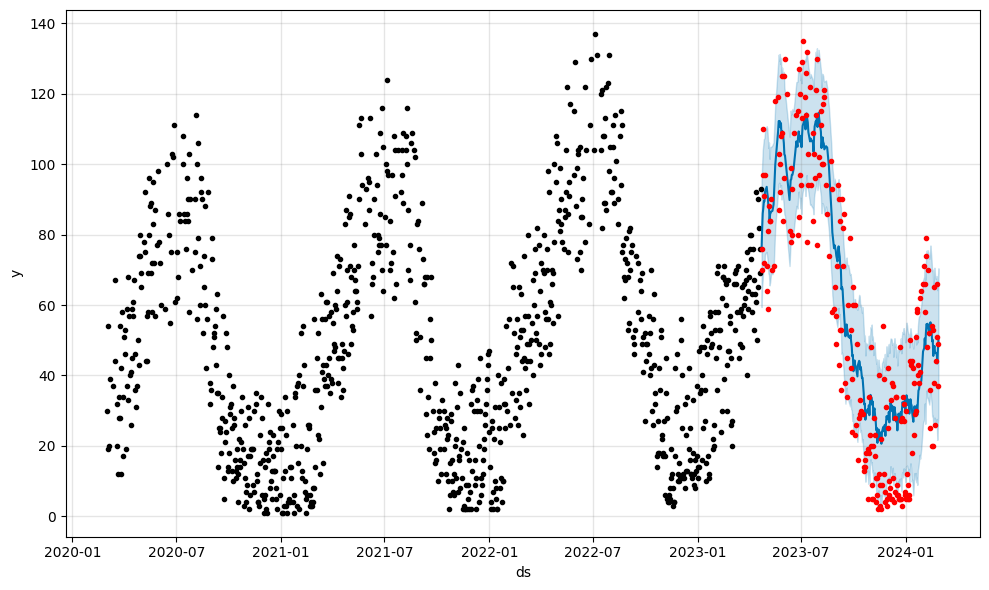

In [37]:
modelo_prophet.plot(predicao)
plt.plot(teste_sem_outliers['ds'], teste_sem_outliers['y'], '.r')
plt.show()

In [38]:
plot_components_plotly(modelo_prophet, predicao)

/usr/local/lib/python3.12/dist-packages/plotly/io/_json.py:560: UserWarning:

Discarding nonzero nanoseconds in conversion.



In [47]:
## Validação Cruzada
from prophet.diagnostics import cross_validation, performance_metrics

df_cv = cross_validation(model=modelo_prophet,
                         initial='365.25 days',
                         period='45 days',
                         horizon='90 days')

df_cv.head()

INFO:prophet:Making 16 forecasts with cutoffs between 2021-03-18 00:00:00 and 2023-01-22 00:00:00


  0%|          | 0/16 [00:00<?, ?it/s]

,ds,yhat,yhat_lower,yhat_upper,y,cutoff
0,2021-03-19,37.440105,20.318336,55.168500,37.0,2021-03-18
1,2021-03-20,36.598534,19.335599,54.322005,61.0,2021-03-18
2,2021-03-21,31.559814,15.800489,48.621099,43.0,2021-03-18
3,2021-03-22,36.089062,19.856275,52.497390,37.0,2021-03-18
4,2021-03-23,34.645841,17.413240,50.359093,61.0,2021-03-18


,y
0,37.0
1,61.0
2,43.0
3,37.0
4,61.0
...,...
1186,90.0
1187,82.0
1188,76.0
1189,69.0


In [52]:
df_cv['cutoff'].unique()

<DatetimeArray>
['2021-03-18 00:00:00', '2021-05-02 00:00:00', '2021-06-16 00:00:00',
 '2021-07-31 00:00:00', '2021-09-14 00:00:00', '2021-10-29 00:00:00',
 '2021-12-13 00:00:00', '2022-01-27 00:00:00', '2022-03-13 00:00:00',
 '2022-04-27 00:00:00', '2022-06-11 00:00:00', '2022-07-26 00:00:00',
 '2022-09-09 00:00:00', '2022-10-24 00:00:00', '2022-12-08 00:00:00',
 '2023-01-22 00:00:00']
Length: 16, dtype: datetime64[ns]

In [53]:
from prophet.diagnostics import performance_metrics

# DataFrame com as métricas de performace
df_metricas = performance_metrics(df_cv)

print("Métricas:")
print("--"*20)
print(f"MSE: {df_metricas['mse'].values[0]:.3f}")
print(f"RMSE: {df_metricas['rmse'].values[0]:.3f}")
print(f"MAE: {df_metricas['mae'].values[0]:.3f}")
print(f"MAPE: {df_metricas['mape'].values[0]:.3f}")
print(f"SMAPE: {df_metricas['smape'].values[0]:.3f}")
print(f"Coverage: {df_metricas['coverage'].values[0]:.3f}")
print("--"*20)


Métricas:
----------------------------------------
MSE: 243.896
RMSE: 15.617
MAE: 12.952
MAPE: 0.366
SMAPE: 0.315
Coverage: 0.683
----------------------------------------


/usr/local/lib/python3.12/dist-packages/prophet/plot.py:547: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.

/usr/local/lib/python3.12/dist-packages/prophet/plot.py:548: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.



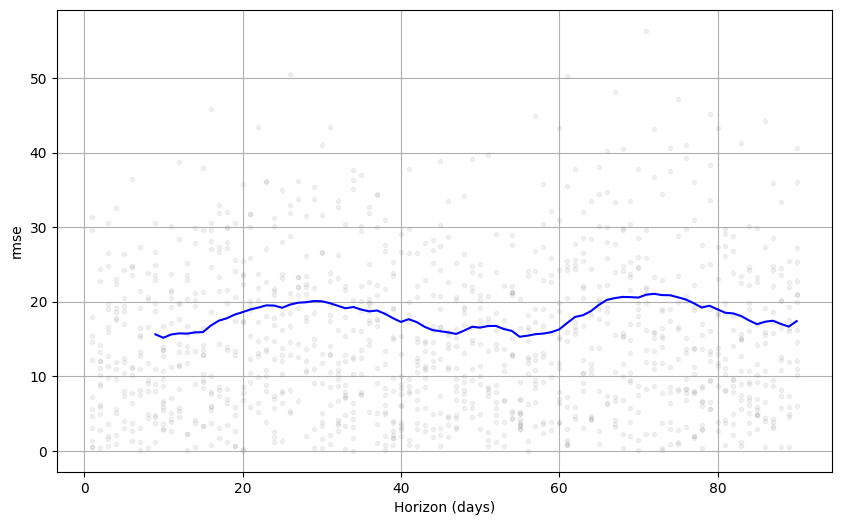

In [62]:
from prophet.plot import plot_cross_validation_metric

fig = plot_cross_validation_metric(df_cv, metric='rmse')
fig.show()

/usr/local/lib/python3.12/dist-packages/prophet/plot.py:547: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.

/usr/local/lib/python3.12/dist-packages/prophet/plot.py:548: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.



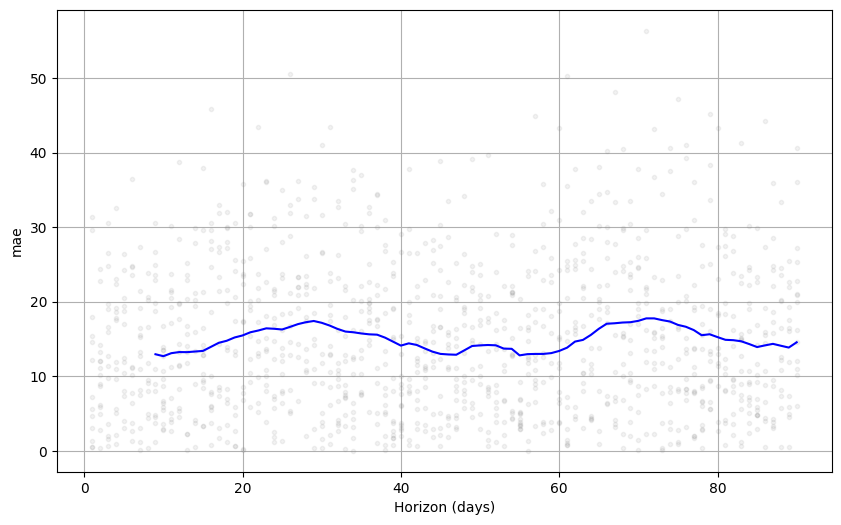

In [63]:
fig = plot_cross_validation_metric(df_cv, metric='mae')
fig.show()

In [67]:
## Modelo Final

modelo_prophet_final = Prophet(changepoint_prior_scale=0.5,
                               yearly_seasonality=20,
                               daily_seasonality=False)

modelo_prophet_final.fit(df_sem_outliers);

In [71]:
import json
from prophet.serialize import model_to_json, model_from_json

with open('modelo_prophet_final2.json', 'w') as f:
    #f.write(model_to_json(modelo_prophet_final))
    json.dump(model_to_json(modelo_prophet_final), f)